# 05 DenseNet121 Baseline
Model setting:
- Backbone: DenseNet121
- Pretrained weights: ImageNet
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 1e-4
- Batch size: 32
- Max epochs: 30
- Early stopping patience: 7
- Best model selection: validation QWK 


In [1]:
EXPERIMENT_NAME = "densenet121_focal_loss_adamw"

NUM_CLASSES = 5
IMAGE_SIZE = 224
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
MAX_EPOCHS = 30
PATIENCE = 7
MONITOR_METRIC = "qwk"

print("Experiment:", EXPERIMENT_NAME)

Experiment: densenet121_focal_loss_adamw


In [2]:
from pathlib import Path
import sys

current_path = Path.cwd()

if current_path.name in ["notebook", "notebooks"]:
    PROJECT_ROOT = current_path.parent

elif (current_path / "data").exists() and (current_path / "models").exists():
    PROJECT_ROOT = current_path

else:
    PROJECT_ROOT = current_path
    while PROJECT_ROOT != PROJECT_ROOT.parent:
        if (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT / "models").exists():
            break
        PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Current path:", current_path)
print("Project root:", PROJECT_ROOT)
print("models folder exists:", (PROJECT_ROOT / "models").exists())
print("densenet.py exists:", (PROJECT_ROOT / "models" / "densenet.py").exists())
print("utils folder exists:", (PROJECT_ROOT / "utils").exists())
print("train_utils.py exists:", (PROJECT_ROOT / "utils" / "train_utils.py").exists())


Current path: D:\760-Group1-main\wanqian
Project root: D:\760-Group1-main
models folder exists: True
densenet.py exists: True
utils folder exists: True
train_utils.py exists: True


In [3]:
import torch
import torch.nn as nn

from models.densenet import get_densenet121, count_trainable_parameters

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = get_densenet121(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=0.3,
)

model = model.to(device)

trainable_params, total_params = count_trainable_parameters(model)

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters:     {total_params:,}")


Device: cpu
Trainable parameters: 6,958,981
Total parameters:     6,958,981


In [4]:
# dataloader
from utils.dataset import get_dataloaders, print_dataset_info

SPLIT_ROOT = PROJECT_ROOT / "data" / "processed" / "split_images"

train_loader, val_loader, test_loader, train_dataset, val_dataset, test_dataset = get_dataloaders(
    split_root=SPLIT_ROOT,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    use_augmentation=True,
)

print_dataset_info(train_dataset, val_dataset, test_dataset)

class_names = train_dataset.classes


Dataset Information
Train images: 1024
Val images:   146
Test images:  294

Class to index mapping:
{'0Normal': 0, '1Doubtful': 1, '2Mild': 2, '3Moderate': 3, '4Severe': 4}

Classes:
['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']


In [5]:
# Focal Loss + AdamW

import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none",
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


criterion = FocalLoss(gamma=2.0)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print("Loss function: Focal Loss, gamma=2.0")
print("Optimizer: AdamW")

Loss function: Focal Loss, gamma=2.0
Optimizer: AdamW


## create densenet

In [6]:
 from utils.train_utils import train_model

SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / f"{EXPERIMENT_NAME}.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=MAX_EPOCHS,
    save_path=SAVE_PATH,
    monitor_metric=MONITOR_METRIC,
    patience=PATIENCE,
    min_delta=1e-4,
)





Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.9096 | Train Acc: 0.3799 | Train Macro F1: 0.3440 | Train QWK: 0.3244
Val Loss:   0.6272 | Val Acc:   0.5959 | Val Macro F1: 0.5095 | Val QWK:   0.6640 | Val MAE:   0.6438
New best model found at epoch 1.
Best val qwk: 0.6640
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_focal_loss_adamw.pth

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0745 | Train Acc: 0.9277 | Train Macro F1: 0.9274 | Train QWK: 0.9668
Val Loss:   0.2371 | Val Acc:   0.7808 | Val Macro F1: 0.7730 | Val QWK:   0.8761 | Val MAE:   0.2945
No improvement in val qwk. Patience: 6/7

Epoch 15/30
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0684 | Train Acc: 0.9297 | Train Macro F1: 0.9306 | Train QWK: 0.9694
Val Loss:   0.2808 | Val Acc:   0.7808 | Val Macro F1: 0.7776 | Val QWK:   0.8878 | Val MAE:   0.2808
No improvement in val qwk. Patience: 7/7

Early stopping triggered
Best epoch: 8
Best val qwk: 0.9353


In [7]:
history_path = PROJECT_ROOT / "outputs" / "results" / f"{EXPERIMENT_NAME}_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

print("Saved history to:", history_path)
history_df

Saved history to: D:\760-Group1-main\outputs\results\densenet121_focal_loss_adamw_history.csv


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.909602,0.627205,0,0,0.379883,0.344018,0.378536,1.243164,0.324351,...,0.509509,0.561771,0.643836,0.663986,59,33,26,0.404110,0.226027,0.178082
1,2,0.484044,0.397098,1,0,0.639648,0.590013,0.622224,0.523438,0.759801,...,0.661917,0.685630,0.376712,0.849259,41,31,10,0.280822,0.212329,0.068493
2,3,0.317505,0.405868,2,0,0.744141,0.723380,0.739430,0.333984,0.866174,...,0.646596,0.685242,0.424658,0.797977,44,32,12,0.301370,0.219178,0.082192
3,4,0.257671,0.278917,2,1,0.761719,0.747895,0.760453,0.306641,0.878748,...,0.730871,0.738345,0.328767,0.869844,38,31,7,0.260274,0.212329,0.047945
4,5,0.223092,0.308199,4,0,0.794922,0.787105,0.794214,0.256836,0.903946,...,0.743439,0.751648,0.321918,0.862193,36,29,7,0.246575,0.198630,0.047945
5,6,0.196369,0.297321,4,1,0.832031,0.824625,0.831277,0.229492,0.901304,...,0.704848,0.746310,0.294521,0.888994,36,31,5,0.246575,0.212329,0.034247
6,7,0.153409,0.262516,6,0,0.857422,0.858532,0.856561,0.175781,0.935722,...,0.792810,0.799015,0.253425,0.898422,29,24,5,0.198630,0.164384,0.034247
7,8,0.140104,0.250661,7,0,0.869141,0.864175,0.868802,0.166016,0.936166,...,0.822751,0.832679,0.191781,0.935260,24,21,3,0.164384,0.143836,0.020548
8,9,0.134432,0.277826,8,0,0.880859,0.881406,0.880589,0.152344,0.940157,...,0.726053,0.742378,0.321918,0.868845,35,27,8,0.239726,0.184932,0.054795
9,10,0.118175,0.269068,8,1,0.880859,0.878074,0.879654,0.159180,0.935740,...,0.792366,0.799398,0.239726,0.910670,29,25,4,0.198630,0.171233,0.027397


## best epoch 

In [8]:
best_idx = history_df["val_qwk"].idxmax()
best_row = history_df.loc[best_idx]

print("Best epoch based on validation QWK:")
print(best_row[[
    "epoch",
    "val_loss",
    "val_accuracy",
    "val_macro_f1",
    "val_weighted_f1",
    "val_mae",
    "val_qwk",
    "val_adjacent_errors",
    "val_distant_errors",
]])



Best epoch based on validation QWK:
epoch                   8.000000
val_loss                0.250661
val_accuracy            0.835616
val_macro_f1            0.822751
val_weighted_f1         0.832679
val_mae                 0.191781
val_qwk                 0.935260
val_adjacent_errors    21.000000
val_distant_errors      3.000000
Name: 7, dtype: float64


## train model

In [9]:
SAVE_PATH = PROJECT_ROOT / "outputs" / "models" / "densenet121_ce_baseline.pth"

model, history_df = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=10,
    save_path=SAVE_PATH,
    monitor_metric="qwk",
)



Epoch 1/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.1240 | Train Acc: 0.8867 | Train Macro F1: 0.8861 | Train QWK: 0.9471
Val Loss:   0.4376 | Val Acc:   0.6781 | Val Macro F1: 0.7000 | Val QWK:   0.8364 | Val MAE:   0.4110
New best model found at epoch 1.
Best val qwk: 0.8364
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_ce_baseline.pth

Epoch 2/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0683 | Train Acc: 0.9385 | Train Macro F1: 0.9372 | Train QWK: 0.9594
Val Loss:   0.2735 | Val Acc:   0.7877 | Val Macro F1: 0.7801 | Val QWK:   0.8945 | Val MAE:   0.2671
No improvement in val qwk. Patience: 5/7

Epoch 10/10
------------------------------------------------------------


Training:   0%|          | 0/32 [00:00<?, ?it/s]

Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Train Loss: 0.0609 | Train Acc: 0.9395 | Train Macro F1: 0.9328 | Train QWK: 0.9631
Val Loss:   0.2343 | Val Acc:   0.8219 | Val Macro F1: 0.8121 | Val QWK:   0.9309 | Val MAE:   0.2055
New best model found at epoch 10.
Best val qwk: 0.9309
Saved best model to: D:\760-Group1-main\outputs\models\densenet121_ce_baseline.pth


save history

In [10]:
history_path = PROJECT_ROOT / "outputs" / "results" / "densenet121_ce_baseline_history.csv"
history_path.parent.mkdir(parents=True, exist_ok=True)

history_df.to_csv(history_path, index=False)

history_df


,epoch,train_loss,val_loss,best_epoch_so_far,epochs_without_improvement,train_accuracy,train_macro_f1,train_weighted_f1,train_mae,train_qwk,...,val_macro_f1,val_weighted_f1,val_mae,val_qwk,val_total_errors,val_adjacent_errors,val_distant_errors,val_total_error_rate,val_adjacent_error_rate,val_distant_error_rate
0,1,0.124014,0.437556,0,0,0.886719,0.886063,0.885881,0.141602,0.947073,...,0.699957,0.682761,0.410959,0.836355,47,37,10,0.321918,0.253425,0.068493
1,2,0.115497,0.261350,1,0,0.885742,0.882248,0.884937,0.150391,0.939332,...,0.765403,0.773465,0.287671,0.886878,32,25,7,0.219178,0.171233,0.047945
2,3,0.107782,0.262618,2,0,0.891602,0.889433,0.891573,0.139648,0.945178,...,0.777793,0.782354,0.280822,0.890466,32,25,7,0.219178,0.171233,0.047945
3,4,0.086120,0.274621,3,0,0.916016,0.919440,0.915750,0.103516,0.962349,...,0.779049,0.790598,0.226027,0.927091,30,28,2,0.205479,0.191781,0.013699
4,5,0.094204,0.311569,4,0,0.909180,0.912310,0.909320,0.111328,0.959810,...,0.799531,0.807045,0.239726,0.900017,28,24,4,0.191781,0.164384,0.027397
5,6,0.086135,0.304289,4,1,0.913086,0.913417,0.912884,0.109375,0.959600,...,0.775629,0.782453,0.273973,0.891176,31,24,7,0.212329,0.164384,0.047945
6,7,0.095257,0.239709,4,2,0.895508,0.892634,0.895405,0.137695,0.945206,...,0.847965,0.857748,0.198630,0.909052,20,14,6,0.136986,0.095890,0.041096
7,8,0.078716,0.274667,4,3,0.923828,0.920223,0.923860,0.104492,0.954673,...,0.816167,0.822524,0.219178,0.909782,25,21,4,0.171233,0.143836,0.027397
8,9,0.068273,0.273512,4,4,0.938477,0.937231,0.938461,0.088867,0.959447,...,0.780103,0.785733,0.267123,0.894501,31,25,6,0.212329,0.171233,0.041096
9,10,0.060890,0.234332,4,5,0.939453,0.932839,0.939144,0.084961,0.963127,...,0.812069,0.815842,0.205479,0.930871,26,23,3,0.178082,0.157534,0.020548


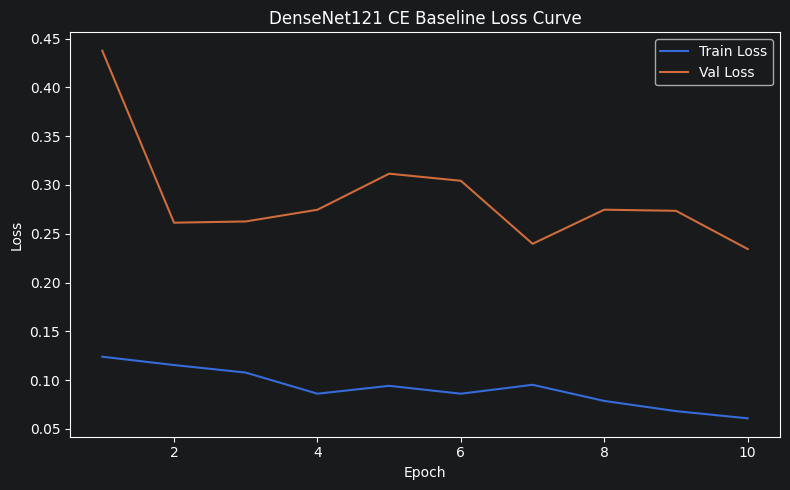

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_ce_baseline_loss.png


In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 CE Baseline Loss Curve")
plt.legend()
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / "densenet121_ce_baseline_loss.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)


In [12]:
from utils.train_utils import train_model, evaluate_model
from utils.metrics import print_metrics
# train set
val_loss, val_metrics, val_true, val_pred = evaluate_model(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
)

print_metrics(val_metrics, title="Validation Metrics")


Validation:   0%|          | 0/5 [00:00<?, ?it/s]

Validation Metrics
accuracy: 0.8219
macro_f1: 0.8121
weighted_f1: 0.8158
mae: 0.2055
qwk: 0.9309
total_errors: 26
adjacent_errors: 23
distant_errors: 3
total_error_rate: 0.1781
adjacent_error_rate: 0.1575
distant_error_rate: 0.0205


In [13]:
from utils.metrics import get_classification_report


# test set
test_loss, test_metrics, test_true, test_pred = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
)

print_metrics(test_metrics, title="Test Metrics")


#classification report 
report = get_classification_report(
    y_true=test_true,
    y_pred=test_pred,
    class_names=class_names,
)

print(report)


Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Test Metrics
accuracy: 0.7687
macro_f1: 0.7572
weighted_f1: 0.7664
mae: 0.2993
qwk: 0.8786
total_errors: 68
adjacent_errors: 53
distant_errors: 15
total_error_rate: 0.2313
adjacent_error_rate: 0.1803
distant_error_rate: 0.0510
              precision    recall  f1-score   support

     0Normal       0.81      0.88      0.84        91
   1Doubtful       0.73      0.70      0.72        88
       2Mild       0.56      0.50      0.53        38
   3Moderate       0.76      0.91      0.83        35
     4Severe       0.97      0.79      0.87        42

    accuracy                           0.77       294
   macro avg       0.77      0.76      0.76       294
weighted avg       0.77      0.77      0.77       294



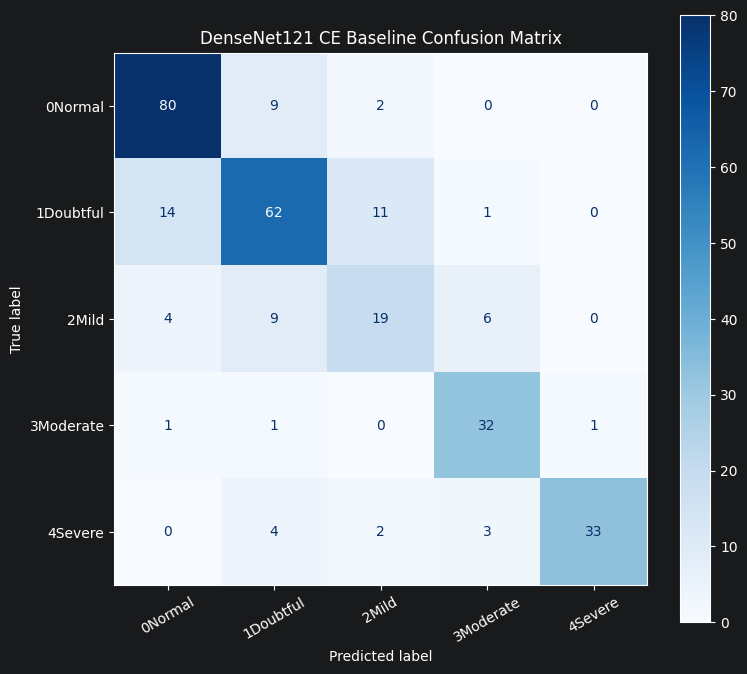

Saved figure to: D:\760-Group1-main\outputs\figures\densenet121_ce_baseline_confusion_matrix.png


In [14]:
# Confusion matrix
from utils.metrics import get_confusion_matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = get_confusion_matrix(test_true, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 7))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.title("DenseNet121 Focal Loss AdamW Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()

figure_path = PROJECT_ROOT / "outputs" / "figures" / f"{EXPERIMENT_NAME}_confusion_matrix.png"
figure_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)
